In [21]:
import pandas as pd
df = pd.read_csv("../datasets/breast_cancer.csv").copy()

In [22]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [23]:
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


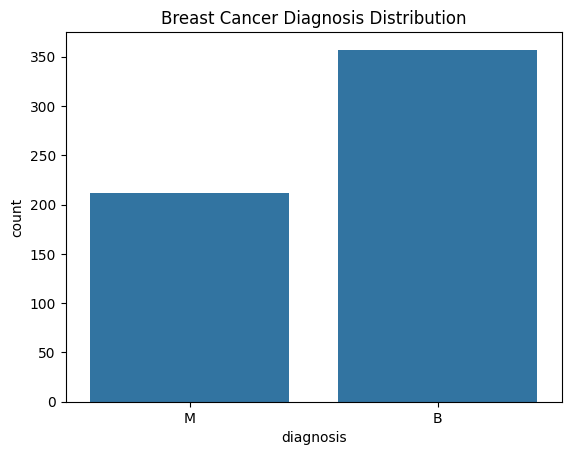

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="diagnosis", data=df)
plt.title("Breast Cancer Diagnosis Distribution")
plt.show()


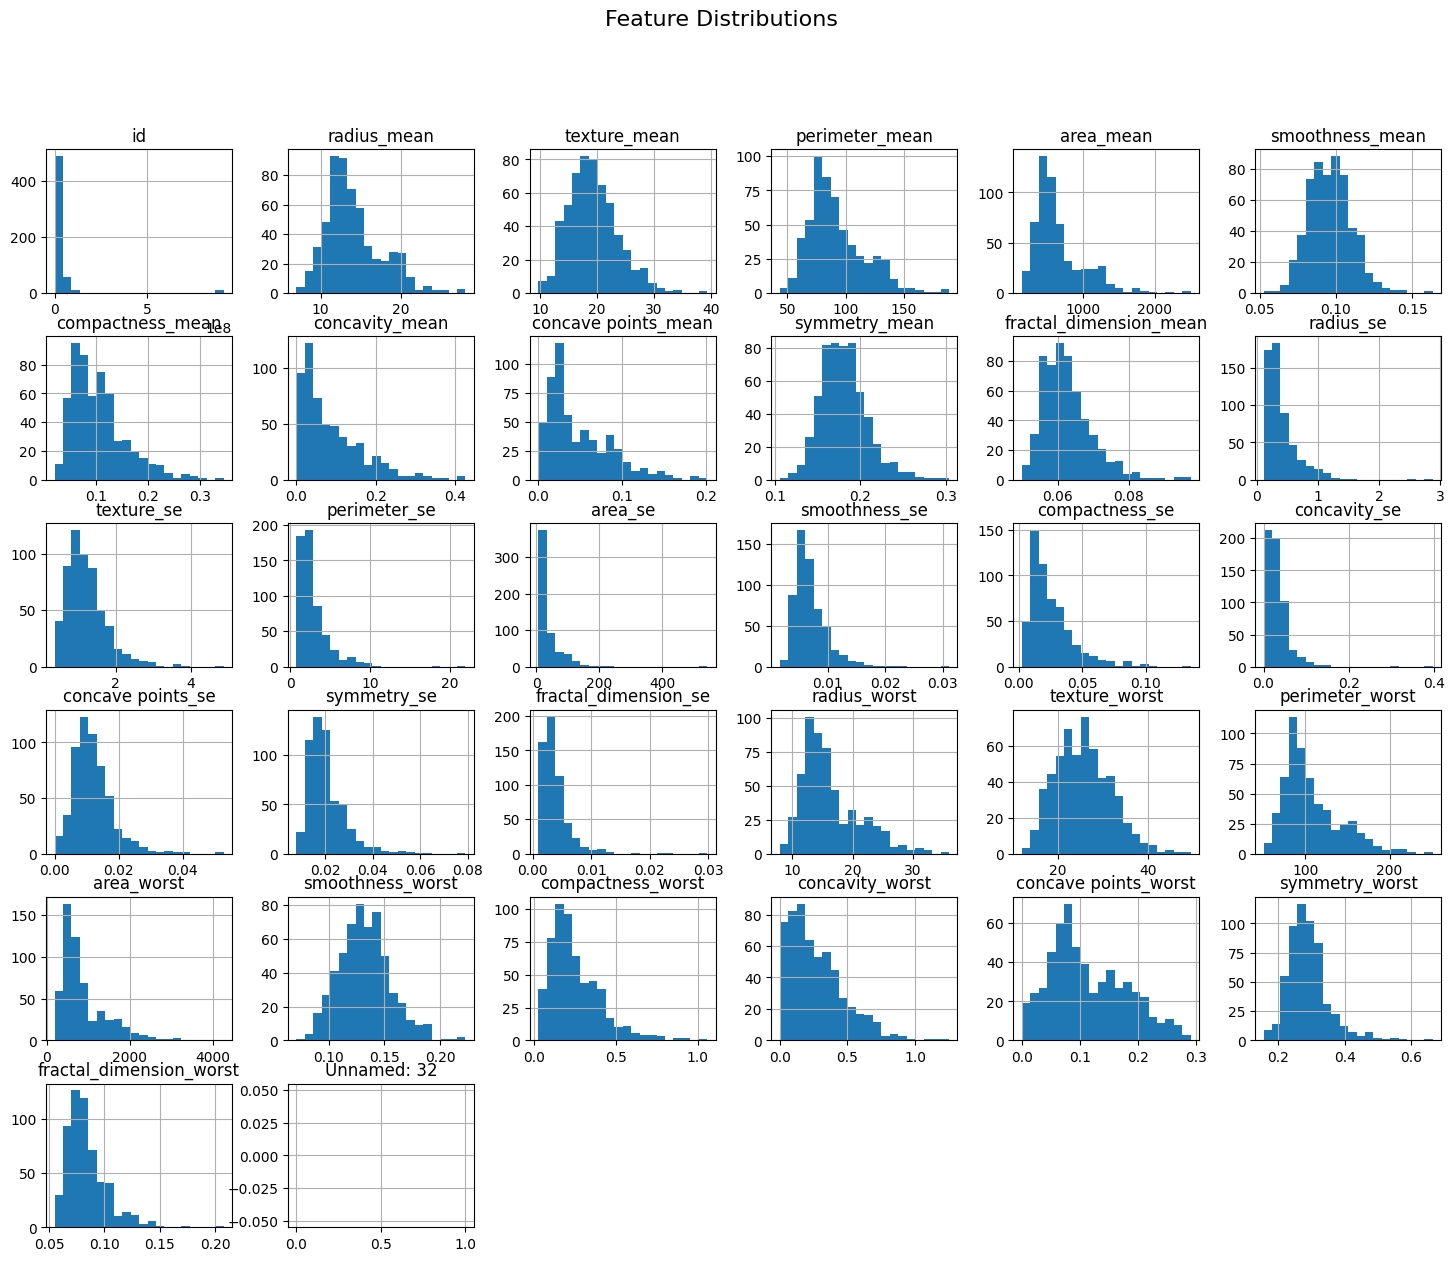

In [25]:
df.hist(figsize=(18, 14), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

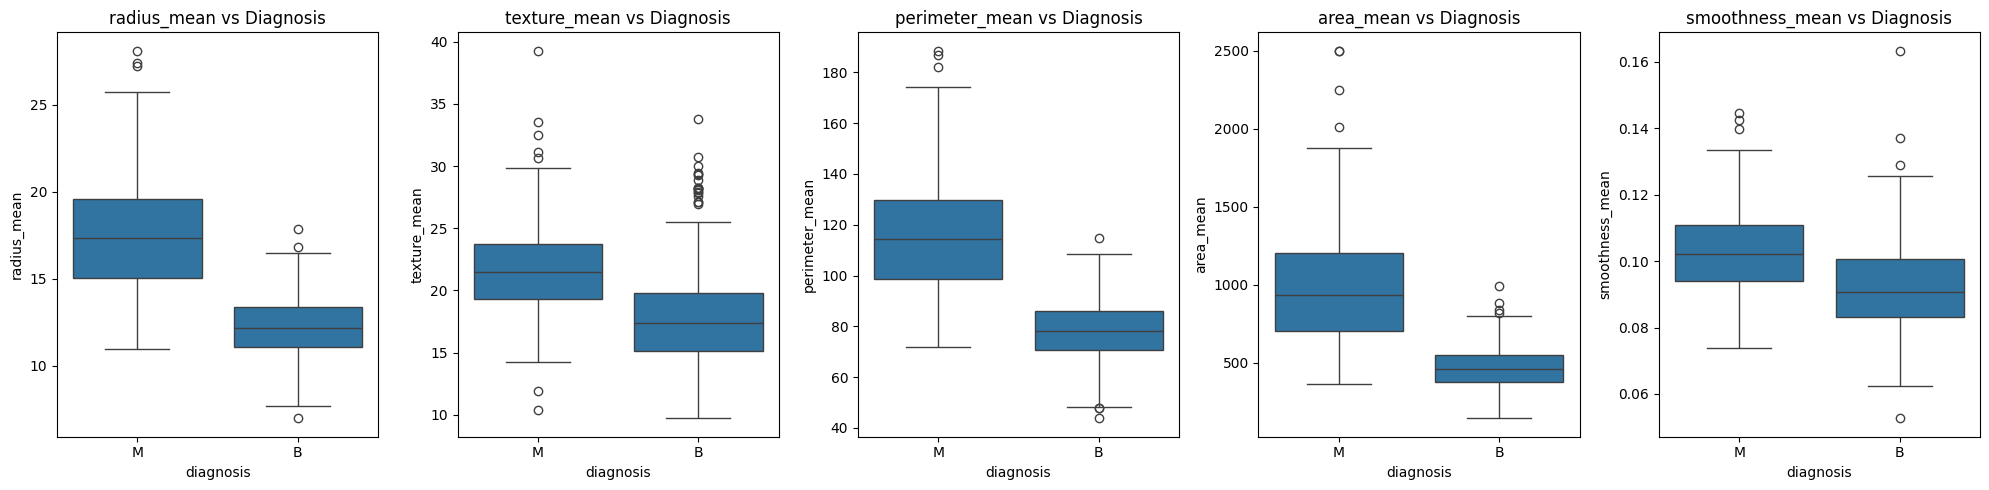

In [26]:
important_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean"
]
fig, axes = plt.subplots(1, len(important_features), figsize=(20, 5))
for ax, col in zip(axes, important_features):
    sns.boxplot(x="diagnosis", y=col, data=df, ax=ax)
    ax.set_title(f"{col} vs Diagnosis")

plt.tight_layout()
plt.show()

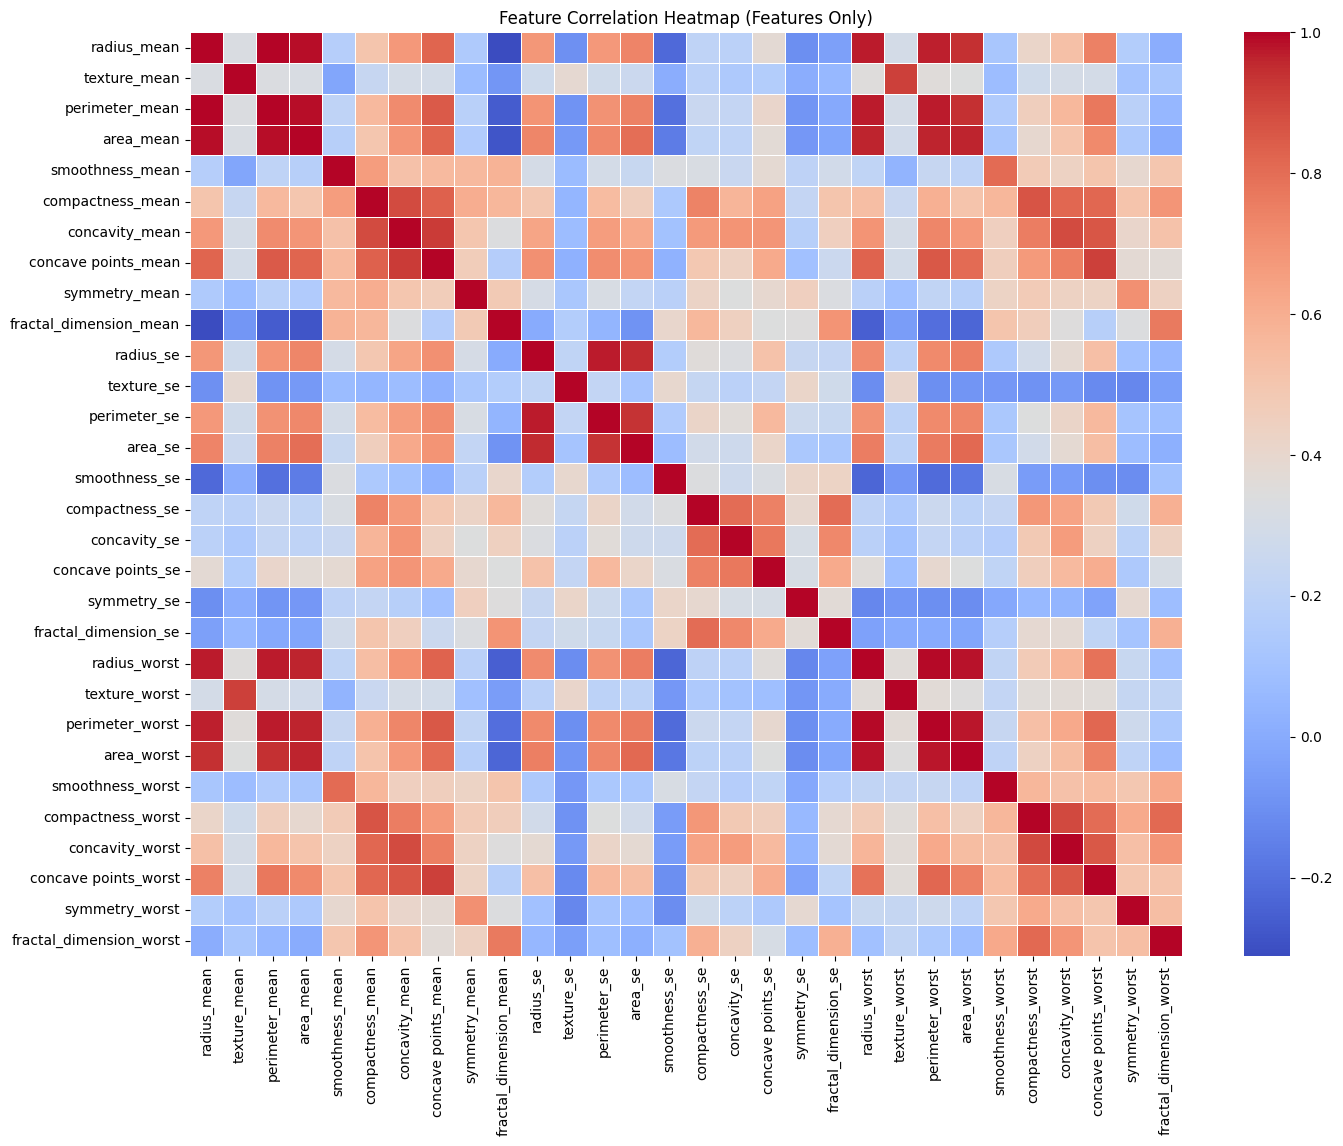

In [27]:
plt.figure(figsize=(16, 12))

corr = df.drop(
    columns=["diagnosis", "id", "Unnamed: 32"],
    errors="ignore"
).corr()

sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Features Only)")
plt.show()


In [28]:
df = df.drop(columns=["id", "Unnamed: 32"])

In [29]:
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

In [30]:
from sklearn.model_selection import train_test_split
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)


In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [32]:
from sklearn.svm import SVC
svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [33]:
from sklearn.metrics import accuracy_score, classification_report

print("SVM Accuracy:", accuracy_score(y_test, svm.predict(X_test_scaled)))
print(classification_report(y_test, svm.predict(X_test_scaled)))

SVM Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [34]:
import joblib

joblib.dump(svm, "../models/breast_cancer_model.pkl")
joblib.dump(scaler, "../models/breast_cancer_scaler.pkl")
joblib.dump(X.columns.tolist(), "../models/breast_cancer_features.pkl")


['../models/breast_cancer_features.pkl']

###################################################### TEST ##########################################

In [35]:
import joblib
import numpy as np
import pandas as pd

model = joblib.load("../models/breast_cancer_model.pkl")
scaler = joblib.load("../models/breast_cancer_scaler.pkl")
features = joblib.load("../models/breast_cancer_features.pkl")

def predict_breast_cancer(patient_data):
    df = pd.DataFrame([patient_data], columns=features)
    df_scaled = scaler.transform(df)

    prob = model.predict_proba(df_scaled)[0][1]
    pred = model.predict(df_scaled)[0]

    label = "Malignant (Cancer)" if pred == 1 else "Benign (Non-cancer)"
    return label, round(prob * 100, 2)


In [36]:
high_risk_patient = [
    19.8, 25.3, 130.0, 1200.0,
    0.11, 0.20, 0.30, 0.15, 0.22, 0.08,

    1.2, 2.5, 8.5, 150.0,
    0.009, 0.05, 0.08, 0.03, 0.05, 0.01,

    25.0, 32.0, 170.0, 2000.0,
    0.14, 0.45, 0.55, 0.25, 0.40, 0.12
]

result, risk = predict_breast_cancer(high_risk_patient)
print(result)
print("Cancer Risk:", risk, "%")


Malignant (Cancer)
Cancer Risk: 98.63 %
